In [1]:
%matplotlib widget
import warnings
import inspect
import matplotlib.pyplot as plt
import IPython.display
import numpy as np
from cued_sf2_lab.familiarisation import load_mat_img, plot_image
from cued_sf2_lab.dct import colxfm

# 8 The Lapped Bi-orthogonal Transform (LBT)

<!-- sorry for the nasty HTML, markdown is bad for figures -->

<figure style="text-align: center">
<div class="row">
<figure class="col-md-4 col-md-offset-1">
<img src="figures/lbt.png" style="max-height: 350px" />
<figcaption>(a) Lapped Bi-orthogonal Transform</figcaption>
</figure>

<figure class="col-md-5 col-md-offset-1">
<img src="figures/pot.png" style="max-height: 350px" />
<figcaption>(b) Photo Overlap Transform and a DCT</figcaption>
</figure>
</div>
<div class="row">
<figcaption>
<br />

Figure 4: (a) An LBT transforms overlapping sections of X to create Y. (b) In some cases
this can be interpreted as pre-filtering with a POT, followed by a DCT.</figcaption></div></figure>


One of the difficulties with the DCT is that it processes each block separately and hence
does not take advantage of any correlation between blocks. A possible solution to this is
to use a _Lapped Bi-orthogonal Transform (LBT)_. These transform overlapping blocks in `X`
to generate smaller non-overlapping blocks in `Y`. In the left-hand figure above, 16 values
in `X` are used to generate each set of 8 values in `Y`.

LBTs are quite complicated to derive and analyse: however one of the most popular forms<sup>3</sup>
can also be represented as a pre-filtering operation before performing the DCT described
in the previous section.
In this case the pre-filtering (or post-filtering for the reverse
operation) is sometimes known as a _Photo Overlap Transform or POT_. A POT followed
by a DCT is then equivalent to a particular type of LBT.

The right-hand figure above demonstrates this. The POT is first performed on a section
of data `X`, shifted by `N/2`, so that it runs across the block boundaries of the subsequent
DCT. Ignoring this block shift for a moment, the forward operation for a 2D image `X` is:

$$Y = C ∗ Pf ∗ X ∗ Pf ′ ∗ C′$$

or in reverse

$$ X = Pr′ ∗ C′ ∗ Y ∗ C ∗ Pr $$

<hr />
<small><sup>3</sup>The type-II fast lapped (bi-)orthogonal transform, or LOT-II</small>


## 8.1 Applying the LBT to images


In [2]:
X, cmaps_dict = load_mat_img(img='lighthouse.mat', img_info='X', cmap_info={'map', 'map2'})
X = X - 128.0

The pre-filtering `Pf ∗ X ∗ Pf′` (with the correct block shift) is straightforward in Python:

```python
t = np.s_[N//2:-N//2]  # this creates a slice object from index N//2 to the -N//2 from end. slice(N//2, -N//2). basically drop the N//2 at the start and end
Xp = X.copy()  # copy the non-transformed edges directly from X
Xp[t,:] = colxfm(Xp[t,:], Pf)
Xp[:,t] = colxfm(Xp[:,t].T, Pf).T
```


This is followed by the DCT `C` as before. In the reverse operation, the inverse DCT `C’` is
performed first, followed by Pr’:

```python
Zp = Z.copy()  #copy the non-transformed edges directly from Z
Zp[:,t] = colxfm(Zp[:,t].T, Pr.T).T
Zp[t,:] = colxfm(Zp[t,:], Pr.T)
```


We have provided a function `pot_ii(N, s)` which will generate a forward (pre-filtering,
`Pf`) and reverse (post-filtering, `Pr`) matrix of size `N` with scaling factor `s`.


In [3]:
from cued_sf2_lab.lbt import pot_ii

Edit your code
for performing DCT analysis so that it can pre-filter `X` with `Pf` before the forward DCT,
then post-filter `Z` with `Pr` after the inverse DCT. Confirm that, without quantisation, this
correctly recreates the original image, i.e. `Zp = X`. Use `Pf, Pr = pot_ii(N)` with the
default scaling value `s`.


In [4]:
from cued_sf2_lab.dct import dct_ii, regroup
from cued_sf2_lab.laplacian_pyramid import bpp, quantise

N=8
#default value of scaling s
scaling=(1+(5**0.5))/2

C8 = dct_ii(N)
Pf, Pr = pot_ii(N, scaling)
t = np.s_[N//2:-N//2]  # skip N/2 border pixels each side; POT can't operate on edges

In [5]:
def lbt_enc(X, C, Pf):
    """Forward LBT: pre-filter with Pf, then DCT with C."""
    N = C.shape[0]
    t = np.s_[N//2:-N//2]
    Xp = X.copy()
    Xp[t,:] = colxfm(Xp[t,:], Pf)
    Xp[:,t] = colxfm(Xp[:,t].T, Pf).T
    Y = colxfm(colxfm(Xp, C).T, C).T
    return Y

def lbt_dec(Y, C, Pr):
    """Inverse LBT: inverse DCT with C', then post-filter with Pr'."""
    N = C.shape[0]
    t = np.s_[N//2:-N//2]
    Z = colxfm(colxfm(Y.T, C.T).T, C.T)
    Zp = Z.copy()
    Zp[:,t] = colxfm(Zp[:,t].T, Pr.T).T
    Zp[t,:] = colxfm(Zp[t,:], Pr.T)
    return Zp

In [6]:
#check max abs value should be small

np.max(np.abs(X - lbt_dec(lbt_enc(X,C8,Pf),C8,Pr)))

np.float64(6.963318810448982e-13)

## 8.2 Quantisation and coding efficiency


The scaling factor `s` determines the degree of bi-orthogonality. If `s = 1` then Pf is the same
as Pr, otherwise `1 < s < 2` weights the relative contributions of `Pf` and `Pr` un-equally.

<div class="alert alert-block alert-danger">

For an 8 × 8 DCT, try implementing an LBT with POT scaling factors varying from $1$
to $2$ ($\sqrt{2}$ is often a good choice). In each case find the quantisation step which makes
the rms error match the directly quantised image. Note the compression ratios and find
the scaling factor which maximises these. Also note the visual features in these images.</div>


In [7]:
#see dct exact same code
def dctbpp(Yr, N):
    total = 0
    size_r, size_c = Yr.shape[0] // N, Yr.shape[1] // N
    for r in range(N):
        for c in range(N):
            Ys = Yr[r*size_r:(r+1)*size_r, c*size_c:(c+1)*size_c]
            total += bpp(Ys) * Ys.size
    return total

  scaling s=1.00, step=23.4, CR=3.024
  scaling s=1.20, step=24.9, CR=3.119
  scaling s=1.40, step=25.9, CR=3.136
  scaling s=1.60, step=26.4, CR=3.085
  scaling s=1.80, step=26.5, CR=2.981
  scaling s=2.00, step=26.4, CR=2.855

Best s=1.42, CR=3.137


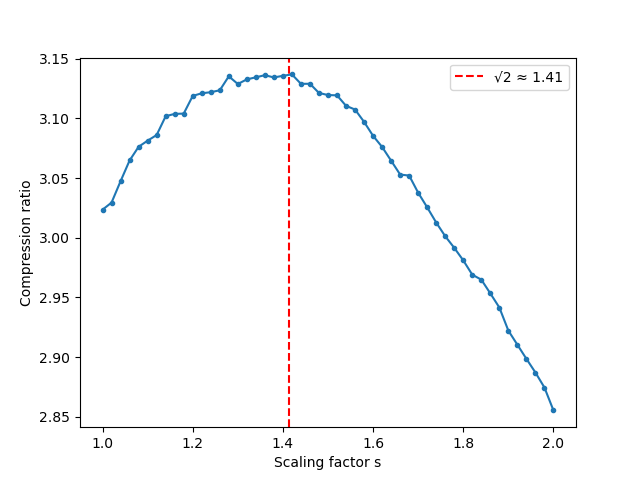

In [8]:
step_grid = np.arange(1, 40, 0.1)
scaling_grid = np.arange(1.0, 2.01, 0.02)
rms_direct = np.std(X - quantise(X, 17))
bits_direct = bpp(quantise(X, 17)) * X.size

crs = []
best_steps = []
for i, s_val in enumerate(scaling_grid):
    Pf_s, Pr_s = pot_ii(N, s_val)
    Y = lbt_enc(X, C8, Pf_s)

    rms_vals = []
    for s in step_grid:
        Zs = lbt_dec(quantise(Y, s), C8, Pr_s)
        rms_vals.append(np.std(X - Zs))

    best_step = step_grid[np.argmin(np.abs(np.array(rms_vals) - rms_direct))]
    Yq = quantise(Y, best_step)
    bits = dctbpp(regroup(Yq, N), N)
    crs.append(bits_direct / bits)
    best_steps.append(best_step)

    if i % 10 == 0:
        print(f"  scaling s={s_val:.2f}, step={best_step:.1f}, CR={crs[-1]:.3f}")

crs = np.array(crs)
best_idx = np.argmax(crs)
print(f"\nBest s={scaling_grid[best_idx]:.2f}, CR={crs[best_idx]:.3f}")

fig, ax = plt.subplots()
ax.plot(scaling_grid, crs, '-o', ms=3)
ax.set(xlabel='Scaling factor s', ylabel='Compression ratio')
ax.axvline(np.sqrt(2), ls='--', c='r', label=f'√2 ≈ {np.sqrt(2):.2f}')
ax.legend()
fig.savefig('zach/images/lbt_cr_vs_scaling.png', dpi=150, bbox_inches='tight')

The optimal scaling factor is $s \approx 1.42$, very close to $\sqrt{2}$, giving $\mathrm{CR} = 3.14$. Even at $s=1$ (LOT, where $P_f = P_r$) the CR is 3.02, already better than the plain DCT's 2.94 — the POT pre-filter improves compression even without bi-orthogonal scaling, because it reduces inter-block correlation before the DCT sees it. The curve drops off steeply past $s \approx 1.5$ as the increasingly asymmetric $P_f / P_r$ weighting distorts the reconstruction.


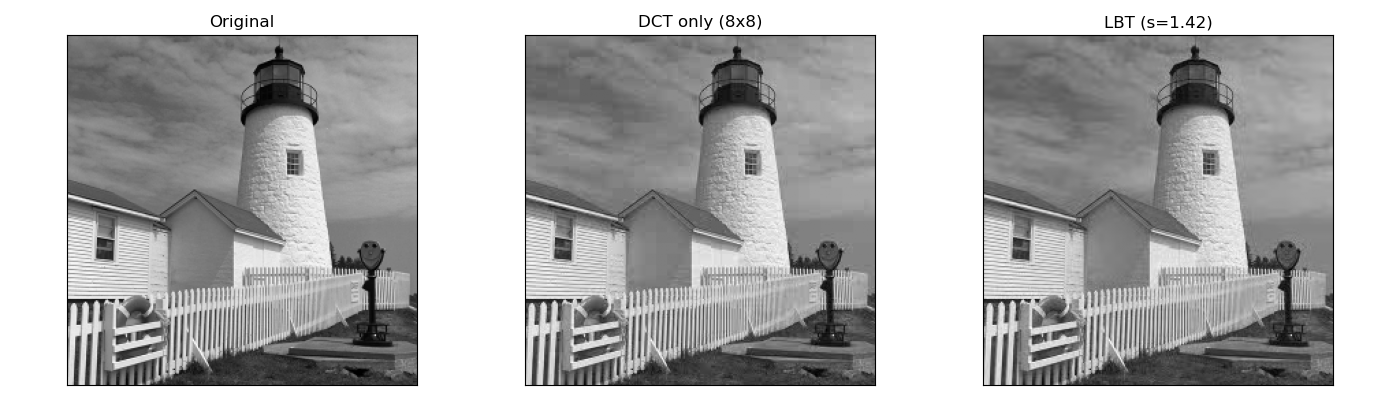

In [9]:
# Reuse best result from above — no redundant search
best_s = scaling_grid[best_idx]
Pf_b, Pr_b = pot_ii(N, best_s)
Z_lbt = lbt_dec(quantise(lbt_enc(X, C8, Pf_b), best_steps[best_idx]), C8, Pr_b)

# Plain DCT at matched RMS (one search needed)
Y_dct = colxfm(colxfm(X, C8).T, C8).T
rms_d = [np.std(X - colxfm(colxfm(quantise(Y_dct, s).T, C8.T).T, C8.T)) for s in step_grid]
step_d = step_grid[np.argmin(np.abs(np.array(rms_d) - rms_direct))]
Z_dct = colxfm(colxfm(quantise(Y_dct, step_d).T, C8.T).T, C8.T)

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
plot_image(X, ax=axs[0]); axs[0].set(title='Original', xticks=[], yticks=[])
plot_image(Z_dct, ax=axs[1]); axs[1].set(title='DCT only (8x8)', xticks=[], yticks=[])
plot_image(Z_lbt, ax=axs[2]); axs[2].set(title=f'LBT (s={best_s:.2f})', xticks=[], yticks=[])
fig.tight_layout()
fig.savefig('zach/images/lbt_visual_compare.png', dpi=150, bbox_inches='tight')

if u look closely u can see for the raw DCT the boundary effects of the 8x8 blocks. whereas lbt dont have


The POT can often improve both compression and block smoothing, since the pre-filter
acts to reduce correlations between each DCT sub-block, whilst the inverse post-filter
acts to remove the discontinuities between sub-blocks. This is rather different from the
operation of the DCT. Investigate this by looking at the basis functions, as you did with
the DCT:


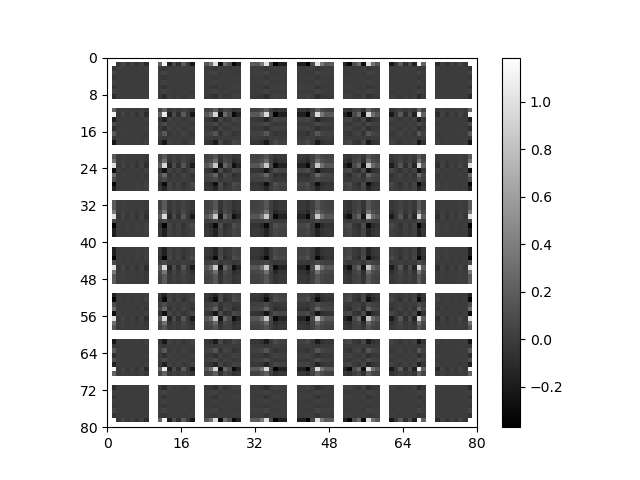

In [10]:
#basis pics for default scaling s which is 1.618 golden ratio

Pf, Pr = pot_ii(8)
bases = np.concatenate([np.full((8,1), np.nan), Pf, np.full((8,1), np.nan)], axis=1)
bases = bases.reshape(-1, 1)
fig, ax = plt.subplots()
im_obj = plot_image(bases @ bases.T, ax=ax)
fig.colorbar(im_obj, ax=ax);
fig.savefig('zach/images/lbt_basis_default.png', dpi=150, bbox_inches='tight')

<div class="alert alert-block alert-danger">

Look at both these bases and the pre-filtered image `Xp`, using different scaling factors
`s`, and comment on the visual effect of varying these scaling factors. You may need to
multiply `Xp` by up to 0.5 to display it better.</div>


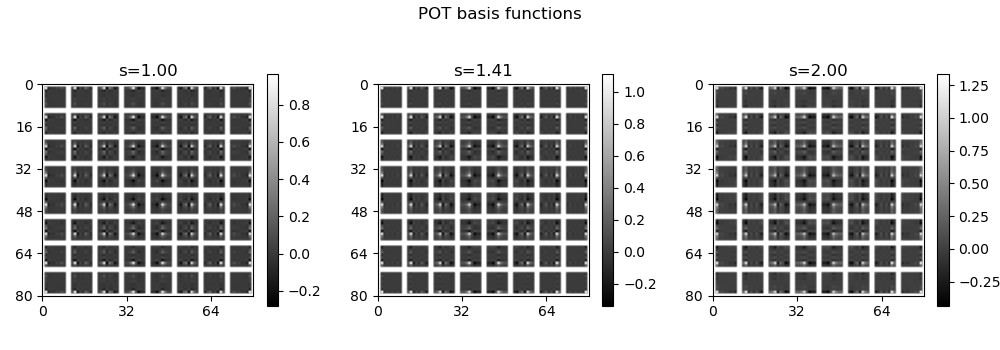

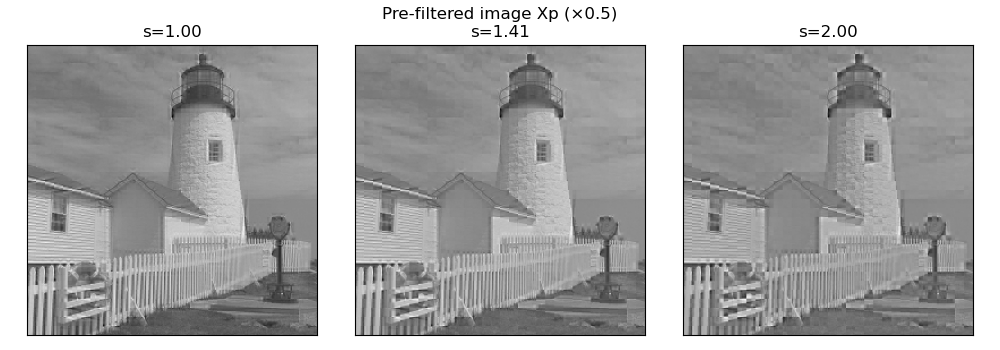

In [11]:
# (a) Plot POT basis functions for different s (reuse cell 20 pattern)
# (b) Plot pre-filtered image Xp for different s (multiply by 0.5 for display)
# Look for: how block-boundary effects change with s

s_values = [1.0, np.sqrt(2), 2.0]

# (a) Basis functions
fig, axs = plt.subplots(1, len(s_values), figsize=(10, 3.5))
for ax, s in zip(axs, s_values):
    Pf_s, _ = pot_ii(8, s)
    bases = np.concatenate([np.full((8,1), np.nan), Pf_s, np.full((8,1), np.nan)], axis=1)
    bases = bases.reshape(-1, 1)
    im = plot_image(bases @ bases.T, ax=ax)
    ax.set(title=f's={s:.2f}')
    fig.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle('POT basis functions')
fig.tight_layout()
fig.savefig('zach/images/lbt_basis_vs_s.png', dpi=150, bbox_inches='tight')

# (b) Pre-filtered images
fig, axs = plt.subplots(1, len(s_values), figsize=(10, 3.5))
for ax, s in zip(axs, s_values):
    Pf_s, _ = pot_ii(N, s)
    Xp = X.copy()
    Xp[t,:] = colxfm(Xp[t,:], Pf_s)
    Xp[:,t] = colxfm(Xp[:,t].T, Pf_s).T
    plot_image(Xp * 0.5, ax=ax)
    ax.set(title=f's={s:.2f}', xticks=[], yticks=[])
fig.suptitle('Pre-filtered image Xp (×0.5)')
fig.tight_layout()
fig.savefig('zach/images/lbt_prefiltered_vs_s.png', dpi=150, bbox_inches='tight')

With this type of POT / DCT combination it is common to use smaller DCT block sizes
but to code several blocks together. Hence a more accurate estimate of the number of bits
is found by always using 16 × 16 blocks, i.e. regroup `Yq` with the correct size `N` to give
`Yr`, but then always use `dctbpp(Yr, 16)`.

<div class="alert alert-block alert-danger">

Investigate the relative visual and compression performance of LBTs with 4 × 4, 8 × 8
and 16 × 16 blocks, using the scaling factor you have previously selected. As before, be
careful to match the rms error with a directly quantised image.</div>


N= 2: step=29.4, bits=78393, CR=2.910
N= 4: step=28.9, bits=64006, CR=3.564
N= 8: step=26.0, bits=66596, CR=3.425


N=16: step=23.0, bits=77333, CR=2.950
N=32: step=20.7, bits=88422, CR=2.580


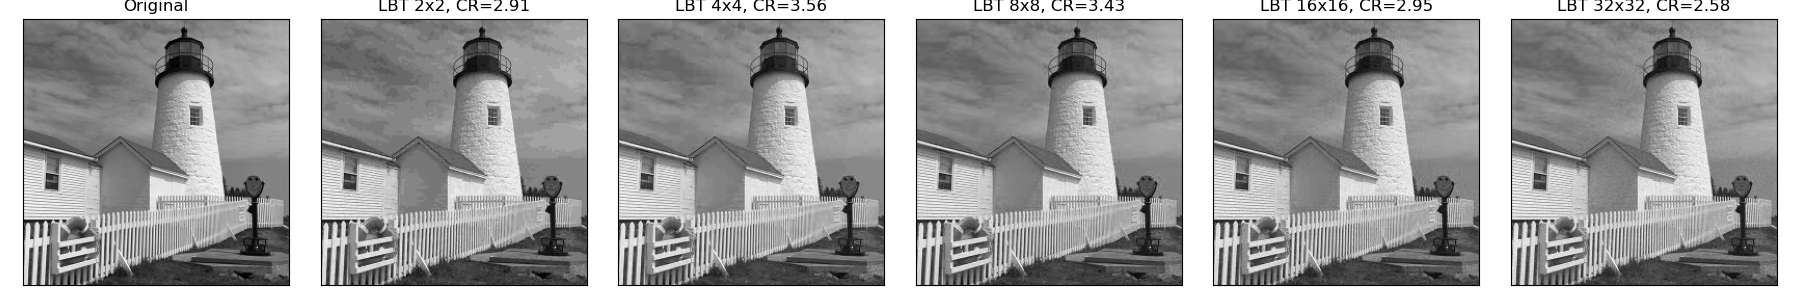

In [12]:
results = {}
for Nblk in [2, 4, 8, 16, 32]:
    Cn = dct_ii(Nblk)
    Pf_n, Pr_n = pot_ii(Nblk, scaling_grid[best_idx])

    Y = lbt_enc(X, Cn, Pf_n)

    rms_vals = []
    for s in step_grid:
        Zp = lbt_dec(quantise(Y, s), Cn, Pr_n)
        rms_vals.append(np.std(X - Zp))

    best_step = step_grid[np.argmin(np.abs(np.array(rms_vals) - rms_direct))]
    Yq = quantise(Y, best_step)
    Zp = lbt_dec(Yq, Cn, Pr_n)

    bits = dctbpp(regroup(Yq, Nblk), 16)
    cr = bits_direct / bits
    results[Nblk] = dict(step=best_step, cr=cr, Z=Zp)
    print(f"N={Nblk:2d}: step={best_step:.1f}, bits={bits:.0f}, CR={cr:.3f}")

fig, axs = plt.subplots(1, 6, figsize=(18, 3))
plot_image(X, ax=axs[0]); axs[0].set(title='Original', xticks=[], yticks=[])
for ax, Nblk in zip(axs[1:], [2, 4, 8, 16, 32]):
    r = results[Nblk]
    plot_image(r['Z'], ax=ax)
    ax.set(title=f'LBT {Nblk}x{Nblk}, CR={r["cr"]:.2f}', xticks=[], yticks=[])
fig.tight_layout()
fig.savefig('zach/images/lbt_block_sizes.png', dpi=150, bbox_inches='tight')

The ordering here is $4 \times 4$ (CR=3.56) > $8 \times 8$ (3.43) > $16 \times 16$ (2.95) — the **opposite** of the DCT, where $8 \times 8$ was best. This is because the POT already handles inter-block correlation, so small blocks no longer pay a penalty for ignoring cross-boundary redundancy. Smaller blocks also mean more coefficients of each type when regrouped, giving better-estimated (and lower) per-sub-image entropies.

Note: the DCT notebook used `dctbpp(Yr, N)` (matching the block size), while here we follow the handout's recommendation of `dctbpp(Yr, 16)` for all LBT sizes. This fixed 16×16 entropy grouping reflects the practical strategy of coding several small blocks together, and is a fairer estimate when the POT has already decorrelated across boundaries.
